In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Interactions

In [92]:
df = pd.read_csv("../data/raw/interactions.csv")

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Number of unique users: {df['pfid'].nunique()}")
print(f"Number of unique streamers: {df['anchor_id'].nunique()}")

Number of rows: 1599759
Number of columns: 11
Number of unique users: 25214
Number of unique streamers: 4053


In [84]:
summary_stats = df.describe()

# check for missing values
missing_values = df.isnull().sum()

missing_values

pfid            0
anchor_id       0
is_follow       0
watch_ts        0
consume_cnt     0
prod_total      0
ent_live_cnt    0
live_cnt        0
ent_rate        0
time_type       0
group           0
dtype: int64

In [89]:
summary_stats

,pfid,anchor_id,is_follow,watch_ts,consume_cnt,prod_total,ent_live_cnt,live_cnt,ent_rate
count,1.599759e+06,1.599759e+06,1.599759e+06,1.599759e+06,1.599759e+06,1.599759e+06,1.599759e+06,1.599759e+06,1.599759e+06
mean,4.605002e+06,4.918140e+06,2.015929e-02,1.976033e+02,1.810829e-01,5.351530e+01,5.461191e-01,1.859468e+01,2.577975e-02
std,1.954890e+06,1.853465e+06,1.405450e-01,9.965445e+02,7.814063e+00,2.766166e+03,5.179551e-01,2.332236e+01,6.192544e-02
min,1.000235e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.760855e+06,3.785024e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.266142e+06,5.550917e+06,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.100000e+01,1.492537e-02
75%,6.243040e+06,6.480110e+06,0.000000e+00,1.400000e+01,0.000000e+00,0.000000e+00,1.000000e+00,3.200000e+01,3.448276e-02
max,6.833356e+06,6.833158e+06,1.000000e+00,8.218100e+04,5.983000e+03,1.109842e+06,2.000000e+01,6.510000e+02,2.000000e+00


In [85]:
df.head()

,pfid,anchor_id,is_follow,watch_ts,consume_cnt,prod_total,ent_live_cnt,live_cnt,ent_rate,time_type,group
0,1000235,4900393,0.0,0.0,0.0,0.0,1.0,41.0,0.024390,H,B
1,1000235,5734817,0.0,4.0,0.0,0.0,1.0,44.0,0.022727,H,B
2,1000235,6017891,0.0,0.0,0.0,0.0,1.0,56.0,0.017857,H,B
3,1000235,6078636,1.0,0.0,0.0,0.0,1.0,42.0,0.023810,H,B
4,1000235,6304788,0.0,0.0,0.0,0.0,1.0,64.0,0.015625,H,B


In [86]:
df[df["ent_live_cnt"] == 0]

,pfid,anchor_id,is_follow,watch_ts,consume_cnt,prod_total,ent_live_cnt,live_cnt,ent_rate,time_type,group
27,1001629,1364340,0.0,0.0,1.0,618.0,0.0,0.0,0.0,H,B
29,1001629,1466696,0.0,0.0,1.0,618.0,0.0,0.0,0.0,H,B
39,1001629,1996506,0.0,0.0,1.0,618.0,0.0,0.0,0.0,H,B
42,1001629,2160061,0.0,0.0,1.0,618.0,0.0,0.0,0.0,H,B
62,1001629,5316682,0.0,0.0,1.0,618.0,0.0,0.0,0.0,H,B
...,...,...,...,...,...,...,...,...,...,...,...
1599754,6833356,6578945,0.0,13.0,0.0,0.0,0.0,0.0,0.0,H,C
1599755,6833356,6691694,0.0,1.0,0.0,0.0,0.0,0.0,0.0,H,C
1599756,6833356,6788332,0.0,11.0,0.0,0.0,0.0,0.0,0.0,H,C
1599757,6833356,6800584,0.0,4.0,0.0,0.0,0.0,0.0,0.0,H,C


In [88]:
df[df["anchor_id"] == 1364340]

,pfid,anchor_id,is_follow,watch_ts,consume_cnt,prod_total,ent_live_cnt,live_cnt,ent_rate,time_type,group
27,1001629,1364340,0.0,0.0,1.0,618.0,0.0,0.0,0.000000,H,B
563,1002573,1364340,0.0,0.0,0.0,0.0,1.0,26.0,0.038462,L,C
2602,1005043,1364340,0.0,0.0,0.0,0.0,1.0,26.0,0.038462,L,B
16642,1081874,1364340,0.0,0.0,0.0,0.0,1.0,26.0,0.038462,H,C
20027,1152101,1364340,0.0,0.0,1.0,520.0,1.0,26.0,0.038462,H,B
...,...,...,...,...,...,...,...,...,...,...,...
1594612,6828473,1364340,0.0,3.0,0.0,0.0,0.0,0.0,0.000000,M,C
1594616,6828478,1364340,0.0,13.0,0.0,0.0,0.0,0.0,0.000000,H,C
1595529,6829277,1364340,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,M,C
1598508,6832356,1364340,0.0,11.0,0.0,0.0,0.0,0.0,0.000000,M,B


In [101]:
df[df["pfid"] == 1001629]["anchor_id"].nunique()

113

## Univariate Analysis

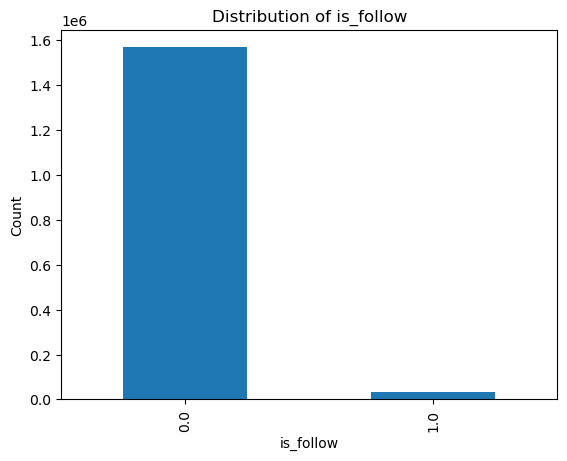

In [56]:
# Bar plot for `is_follow`
df["is_follow"].value_counts().plot(kind='bar')
plt.xlabel('is_follow')
plt.ylabel('Count')
plt.title('Distribution of is_follow')
plt.show()

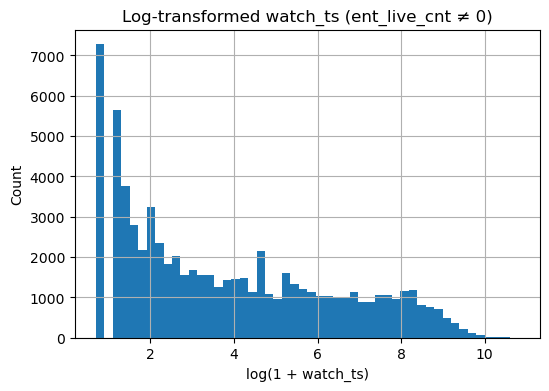

In [67]:
# plot log-transformed `watch_ts` after filtering out `ent_live_cnt == 0` and `watch_ts > 0`
filtered = df[(df["ent_live_cnt"] != 0) & (df["watch_ts"] > 0)]
log_watch_ts = np.log1p(filtered["watch_ts"])

plt.figure(figsize=(6, 4))
log_watch_ts.hist(bins=50)
plt.title('Log-transformed watch_ts (ent_live_cnt ≠ 0)')
plt.xlabel('log(1 + watch_ts)')
plt.ylabel('Count')
plt.show()

In [68]:
df.columns

Index(['pfid', 'anchor_id', 'is_follow', 'watch_ts', 'consume_cnt',
       'prod_total', 'ent_live_cnt', 'live_cnt', 'ent_rate', 'time_type',
       'group'],
      dtype='object')

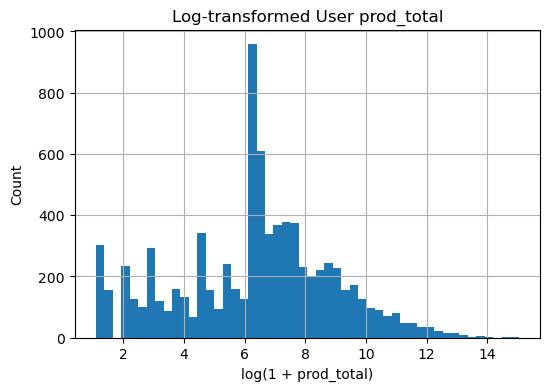

In [71]:
# Aggregate prod_total at the user level
user_prod_total = df.groupby('pfid')['prod_total'].sum()

# Filter out users with prod_total <= 0
user_prod_total = user_prod_total[user_prod_total > 0]

# Log-transform
log_user_prod_total = np.log1p(user_prod_total)

# Plot
plt.figure(figsize=(6, 4))
log_user_prod_total.hist(bins=50)
plt.title('Log-transformed User prod_total')
plt.xlabel('log(1 + prod_total)')
plt.ylabel('Count')
plt.show()

## Bivariate Analysis

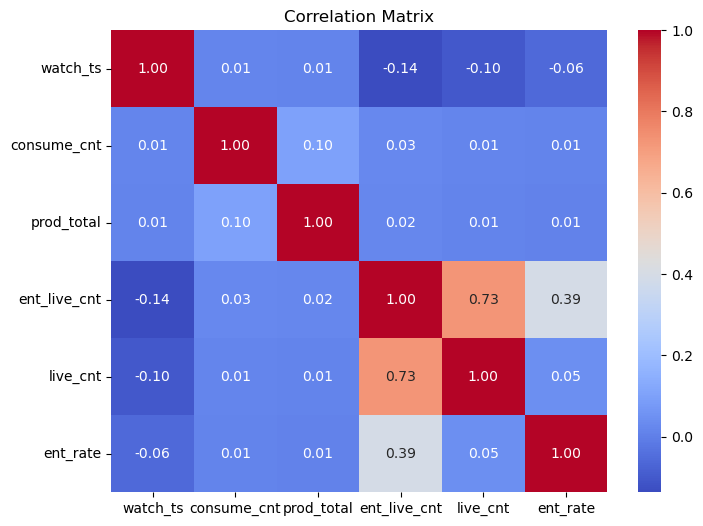

In [72]:
columns = ["watch_ts", "consume_cnt", "prod_total", "ent_live_cnt", "live_cnt", "ent_rate"]
correlation_matrix = df[columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=columns, yticklabels=columns)
plt.title("Correlation Matrix")
plt.show()

/var/folders/5n/2n9yk399177_0hls7bm2y3t00000gn/T/ipykernel_49146/3524344140.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='is_follow', y='watch_ts', data=filtered, inner='quartile', scale='width')


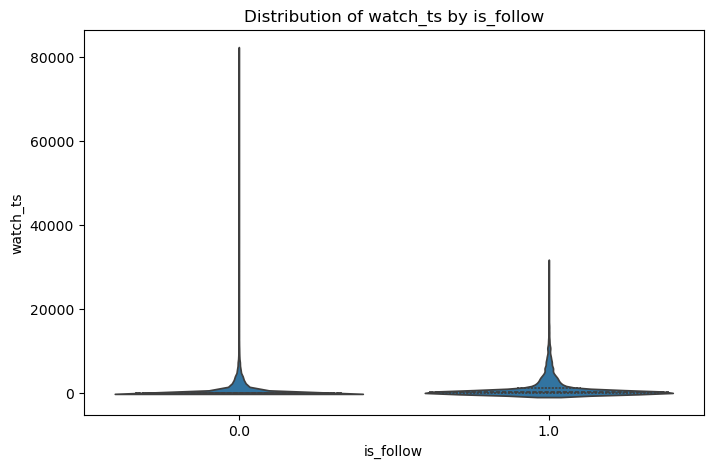

In [74]:
filtered = df[df["watch_ts"] > 0]

plt.figure(figsize=(8, 5))
sns.violinplot(x='is_follow', y='watch_ts', data=filtered, inner='quartile', scale='width')
plt.xlabel('is_follow')
plt.ylabel('watch_ts')
plt.title('Distribution of watch_ts by is_follow')
plt.show()

## User-level Aggregation (by `pfid`)

In [93]:
user_agg = df.groupby("pfid").agg({
    "watch_ts": "sum", 
    "consume_cnt": "sum", 
    "prod_total": "sum",
    "ent_live_cnt": "sum",
    "anchor_id": pd.Series.nunique,
    "is_follow": "sum", 
}).rename(columns={
    "anchor_id": "unique_streamers",
    "is_follow": "total_followed_streamers"
})

user_agg["avg_watch_per_entry"] = user_agg["watch_ts"] / user_agg["ent_live_cnt"]

In [94]:
user_agg.describe()

,watch_ts,consume_cnt,prod_total,ent_live_cnt,unique_streamers,total_followed_streamers,avg_watch_per_entry
count,2.521400e+04,25214.000000,2.521400e+04,25214.000000,25214.000000,25214.000000,2.518900e+04
mean,1.253739e+04,11.489212,3.395399e+03,34.649758,34.176727,1.279051,inf
std,3.985851e+04,99.903926,4.193350e+04,83.655149,81.859079,6.991659,NaN
min,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000e+00
25%,6.700000e+01,0.000000,0.000000e+00,3.000000,3.000000,0.000000,1.221429e+01
50%,5.140000e+02,0.000000,0.000000e+00,10.000000,10.000000,0.000000,6.416667e+01
75%,6.158750e+03,1.000000,7.975000e+01,26.000000,26.000000,1.000000,3.691562e+02
max,1.621916e+06,6682.000000,3.368457e+06,1276.000000,1238.000000,361.000000,inf


## Avg. number of interacted streamer each user has

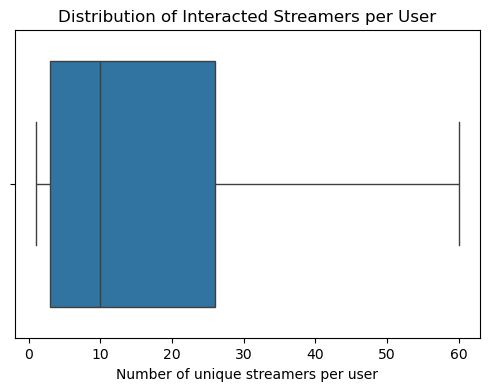

In [ ]:
# Box plot of the number of unique streamers each user has interacted with
# (filter outliers for better visualization)
plt.figure(figsize=(6, 4))
sns.boxplot(x=user_agg["unique_streamers"], showfliers=False)
plt.xlabel("Number of unique streamers per user")
plt.title("Distribution of Interacted Streamers per User")
plt.show()

In [95]:
user_agg[user_agg["unique_streamers"] == 1238]

,watch_ts,consume_cnt,prod_total,ent_live_cnt,unique_streamers,total_followed_streamers,avg_watch_per_entry
pfid,,,,,,,
5700310,169285.0,252.0,10219.0,1276.0,1238,15.0,132.668495


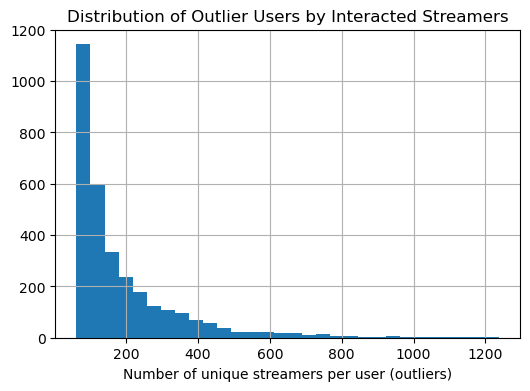

In [98]:
# Calculate IQR and outlier bounds
q1 = user_agg["unique_streamers"].quantile(0.25)
q3 = user_agg["unique_streamers"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Extract outliers
outliers = user_agg[(user_agg["unique_streamers"] < lower_bound) | (user_agg["unique_streamers"] > upper_bound)]["unique_streamers"]

# Plot outlier distribution
plt.figure(figsize=(6, 4))
outliers.hist(bins=30)
plt.xlabel("Number of unique streamers per user (outliers)")
plt.title("Distribution of Outlier Users by Interacted Streamers")
plt.show()

## Streamer-level Aggregation (by `anchor_id`)

In [25]:
streamer_agg = df.groupby('anchor_id').agg({
    'watch_ts': 'mean',
    'consume_cnt': 'mean',
    'prod_total': 'sum',
    'ent_rate': 'mean',
    'pfid': pd.Series.nunique,
    'is_follow': 'sum'
}).rename(columns={'pfid': 'unique_viewers', 'is_follow': 'total_followers'})

streamer_agg

,watch_ts,consume_cnt,prod_total,ent_rate,unique_viewers,total_followers
anchor_id,,,,,,
0,0.000000,0.000000,0.0,0.000000,364,0.0
999,0.000000,0.000000,0.0,0.000000,1,0.0
1000033,0.000000,0.000000,0.0,0.000000,1,0.0
1001125,156.121339,0.119770,89844.0,0.025702,998,32.0
1001311,13.176471,0.000000,0.0,0.294118,9,0.0
...,...,...,...,...,...,...
6831929,39.461538,0.000000,0.0,0.069231,8,0.0
6832198,224.500000,0.236111,34.0,0.513889,38,2.0
6832233,16.882353,0.029412,2.0,0.183824,25,0.0


## Interaction Analysis (User-Streamer Pair)